In [1]:
#dataset = https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who

#importing libraries:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [2]:
#downloading dataset:
kagglehub.dataset_download('kumarajarshi/life-expectancy-who')

100%|██████████| 119k/119k [00:00<00:00, 248kB/s]

Extracting files...


'C:\\Users\\Lenovo\\.cache\\kagglehub\\datasets\\kumarajarshi\\life-expectancy-who\\versions\\1'

In [28]:
#importing datastet:
df = pd.read_csv(r'C:\Users\Lenovo\.cache\kagglehub\datasets\kumarajarshi\life-expectancy-who\versions\1\Life Expectancy Data.csv').dropna()
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [29]:
#knowing only numeric columns:
df.select_dtypes(include = 'number').columns

Index(['Year', 'Life expectancy ', 'Adult Mortality', 'infant deaths',
       'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles ', ' BMI ',
       'under-five deaths ', 'Polio', 'Total expenditure', 'Diphtheria ',
       ' HIV/AIDS', 'GDP', 'Population', ' thinness  1-19 years',
       ' thinness 5-9 years', 'Income composition of resources', 'Schooling'],
      dtype='object')

In [30]:
df.select_dtypes(include = 'number').head()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,2015,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,2014,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,2013,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,2012,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,2011,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [31]:
#defining x and y for prediction:
x = df.select_dtypes(include = 'number').drop(columns = ['Life expectancy '])
y = df['Life expectancy ']

In [36]:
#splitting data for training and testing:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

In [37]:
#creating ai model:
model = LinearRegression()

In [38]:
#training ai model:
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [39]:
#testing ai model on testing data:
predictions = model.predict(x_test)

# **Evaluating AI Model**

Text(0, 0.5, 'predicted values')

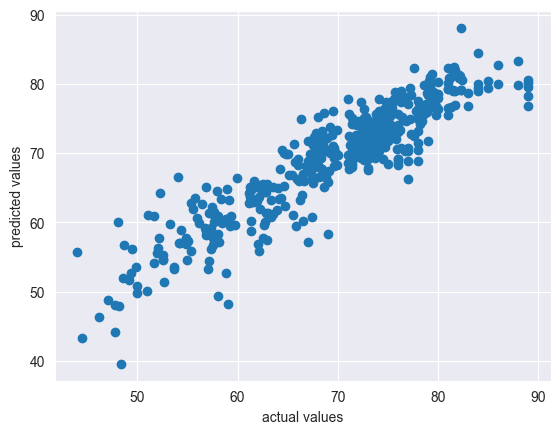

In [40]:
#scatter plot of actual values vs predicted values:
plt.scatter(y_test, predictions)
plt.xlabel('actual values')
plt.ylabel('predicted values')

<Axes: xlabel='Life expectancy ', ylabel='Count'>

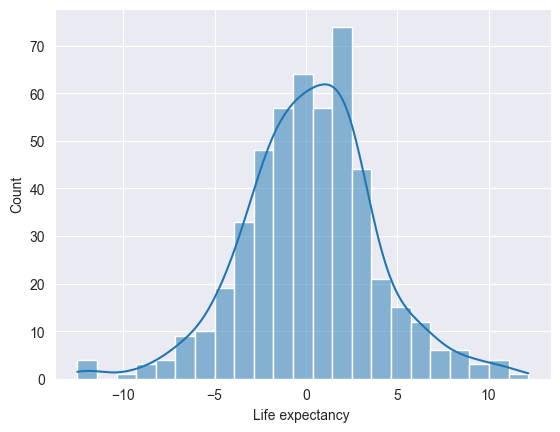

In [41]:
#histogram of residuals:
residuals = y_test - predictions
sns.histplot(residuals, kde = True)

In [43]:
#mae, rmse
mae = metrics.mean_absolute_error(y_test, predictions)
rmse = np.sqrt(metrics.mean_squared_error(y_test, predictions))
mae_percentage = (mae / y.mean()) * 100
rmse_percentage = (rmse / y.mean()) * 100
print(f'mae percentage = {mae_percentage}')
print(f'rmse percentage = {rmse_percentage}')

mae percentage = 4.0123404167069125
rmse percentage = 5.269836716689423


# **Conclusion**

In [44]:
#what should be increased or what should be decreased? to increase life expectancy?
pd.DataFrame(data = model.coef_, index = x.columns, columns = ['Coefficient'])

#conclusion = decrease alcohol

,Coefficient
Year,-1.147179e-01
Adult Mortality,-1.613553e-02
infant deaths,8.815749e-02
Alcohol,-1.375276e-01
percentage expenditure,4.165396e-04
Hepatitis B,-4.836989e-03
Measles,-1.041487e-05
BMI,2.431168e-02
under-five deaths,-6.613288e-02
Polio,5.255426e-03
